# 02. Sampling Distributions and Asymptotics

Notebook 01 established the basic inferential problem: a sample gives us an estimate, but a decision depends on an unknown population quantity. We now go one level deeper. We now study the **distribution of the estimator itself**.

That move is essential. The raw data have a distribution, but the sample mean, sample proportion, and other statistics also have distributions because they would vary from one sample to another. Statistical inference works by understanding those repeated-sample distributions well enough to approximate uncertainty from the single sample we actually observed.

In practice, much of modern inference relies on **asymptotics**: approximations that become accurate as sample size grows. Those approximations are often powerful, but they are not magic. The examples show both why they work and where they can fail.


## Learning Objectives

After working through this lecture, you should be able to:

1. Distinguish the distribution of the data from the sampling distribution of an estimator.
2. Explain the law of large numbers and the central limit theorem in operational terms.
3. Compute and interpret standard errors for sample means and sample proportions.
4. Use asymptotic normal approximations to build uncertainty intervals.
5. Compare asymptotic intervals with bootstrap intervals for moderate sample sizes.
6. Diagnose when asymptotic approximations become unreliable, especially for rare events.
7. Translate asymptotic evidence into a recommendation that acknowledges both uncertainty and approximation limits.


### Dataset and Experiment Design

We reuse the synthetic enterprise-support population from Notebook 01. Each row is a support ticket with operational context and outcomes such as resolution time, SLA breach, and a rarer critical-failure indicator. The hidden population is treated as the target process, while repeated audit samples represent the evidence an analyst might actually receive.

The experiment studies estimators, with individual tickets serving as the raw material. We repeatedly draw samples of different sizes and study the distribution of the sample mean, sample breach rate, and rare-event rate. That repeated-sampling setup makes the law of large numbers, central limit theorem, standard errors, and asymptotic intervals visible in a decision setting.

The rare-event outcome is included on purpose. It shows that large-sample approximations can behave well for common metrics while remaining fragile for low-probability operational failures.

In [1]:
# Load the libraries and notebook settings used in the examples below.
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'notebooks' / '_shared' / 'display.py').exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

from notebooks._shared.display import smart_display

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f"{x:0.3f}")
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 160)
np.random.seed(2026)


def make_support_population(n=60_000, seed=310, sla_minutes=60):
    """
    Construct the support population object used in this lecture.
    
    Parameters:
        n: Number of observations, rows, or simulated units to generate.
        seed: Random seed used to make the simulation or resampling reproducible.
        sla_minutes: Decision or statistical threshold used to define the target, interval, or rule.
    
    Returns:
        A pandas DataFrame representing the simulated support population, including covariates, operational outcomes, and ground-truth targets used later for inference checks.
    
    Idea:
        Create a known synthetic population so sample estimates, intervals, likelihoods, and inference procedures can be checked against ground truth.
    """
    rng = np.random.default_rng(seed)

    seller_tier = rng.choice(['growth', 'enterprise'], size=n, p=[0.72, 0.28])
    severity = rng.choice(['routine', 'complex', 'urgent'], size=n, p=[0.55, 0.32, 0.13])
    region = rng.choice(['North', 'South', 'West', 'Central'], size=n, p=[0.24, 0.22, 0.29, 0.25])
    channel = rng.choice(['chat', 'email', 'phone'], size=n, p=[0.44, 0.31, 0.25])

    queue_pressure = np.clip(
        rng.normal(0.0, 0.85, n)
        + np.where(region == 'West', 0.18, 0.0)
        + np.where(region == 'South', 0.08, 0.0),
        -1.5,
        2.8,
    )
    analyst_tenure_years = rng.gamma(shape=3.5, scale=1.3, size=n)
    automation_assist = rng.binomial(
        1,
        p=np.where(severity == 'routine', 0.72, np.where(severity == 'complex', 0.48, 0.22)),
        size=n,
    )

    severity_base = {'routine': 30, 'complex': 48, 'urgent': 70}
    tier_effect = {'growth': -2, 'enterprise': 4}
    channel_effect = {'chat': -5, 'email': 2, 'phone': 7}
    region_effect = {'North': -2, 'South': 2, 'West': 4, 'Central': 0}

    service_noise = rng.normal(0, 7, n) + rng.gamma(2.3, 2.6, n)

    resolution_minutes = (
        np.vectorize(severity_base.get)(severity)
        + np.vectorize(tier_effect.get)(seller_tier)
        + np.vectorize(channel_effect.get)(channel)
        + np.vectorize(region_effect.get)(region)
        + 5.8 * queue_pressure
        - 1.8 * analyst_tenure_years
        - 6.0 * automation_assist
        + service_noise
    )
    resolution_minutes = np.clip(resolution_minutes, 5, None)

    sla_breach = (resolution_minutes > sla_minutes).astype(int)
    critical_failure = (resolution_minutes > 90).astype(int)
    cost_per_ticket = 14 + 0.72 * resolution_minutes + 18 * sla_breach + 0.12 * np.maximum(resolution_minutes - sla_minutes, 0) ** 1.1

    return pd.DataFrame(
        {
            'seller_tier': seller_tier,
            'severity': severity,
            'region': region,
            'channel': channel,
            'queue_pressure': queue_pressure,
            'analyst_tenure_years': analyst_tenure_years,
            'automation_assist': automation_assist,
            'resolution_minutes': resolution_minutes,
            'sla_breach': sla_breach,
            'critical_failure': critical_failure,
            'cost_per_ticket': cost_per_ticket,
        }
    )


def normal_pdf(x):
    """
    Evaluate the normal probability density function at the supplied values.
    
    Parameters:
        x: Input value or array passed to the mathematical transform.
    
    Returns:
        The normal-density value or array evaluated at the supplied point or grid.
    
    Idea:
        Evaluate the normal density used as a visual or likelihood reference for approximate sampling behavior.
    """
    return np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi)


def mean_interval_normal(values, z=1.96):
    """
    Compute a normal-approximation confidence interval for a sample mean.
    
    Parameters:
        values: Numeric values used by the statistic or interval helper.
        z: Normal critical value or z-score used in the interval or tail-probability calculation.
    
    Returns:
        A tuple containing the sample mean, its standard error, and a normal-approximation confidence interval.
    
    Idea:
        Use the normal approximation to show the classical link between standard errors, sampling distributions, and interval estimates.
    """
    arr = np.asarray(values)
    estimate = arr.mean()
    se = arr.std(ddof=1) / np.sqrt(len(arr))
    return estimate, se, (estimate - z * se, estimate + z * se)


def prop_interval_wald(values, z=1.96):
    """
    Compute a Wald confidence interval for a sample proportion.
    
    Parameters:
        values: Numeric values used by the statistic or interval helper.
        z: Normal critical value or z-score used in the interval or tail-probability calculation.
    
    Returns:
        A tuple containing the observed proportion, its standard error, and the Wald interval endpoints.
    
    Idea:
        Use the basic normal approximation for a proportion as a familiar benchmark whose weaknesses can be diagnosed.
    """
    arr = np.asarray(values)
    estimate = arr.mean()
    se = np.sqrt(estimate * (1 - estimate) / len(arr))
    return estimate, se, (estimate - z * se, estimate + z * se)


def bootstrap_distribution(values, reps=3000, seed=0):
    """
    Generate bootstrap-based distribution results from resampled data.
    
    Parameters:
        values: Numeric values used by the statistic or interval helper.
        reps: Number of repeated samples, bootstrap draws, or simulation replications.
        seed: Random seed used to make the simulation or resampling reproducible.
    
    Returns:
        A NumPy array of bootstrap sample means for the supplied data.
    
    Idea:
        Approximate an estimator's sampling behavior from the observed sample when the true population cannot be repeatedly sampled.
    """
    arr = np.asarray(values)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(arr), size=(reps, len(arr)))
    return arr[idx].mean(axis=1)

## 1. The Data Distribution Is Not the Sampling Distribution

The observed ticket times have one distribution. The **sample mean** of those times has another.

That distinction can be summarized this way:

| Object | What varies? | What it describes |
|---|---|---|
| Data distribution | Ticket-level outcomes | The variability across individual tickets |
| Sampling distribution of an estimator | The statistic across repeated samples | How much the estimate itself would move if we reran the audit |
| Asymptotic approximation | A large-sample mathematical surrogate for the sampling distribution | A practical way to quantify uncertainty from one sample |

If we care about uncertainty around the mean resolution time or the breach rate, the relevant object is not the raw ticket histogram alone. It is the sampling distribution of the corresponding estimator.


## 2. Setup: The Same Support System, Now Viewed Through Sampling Theory

We reuse the synthetic enterprise-support system from notebook 01. The hidden population provides the instructor's truth. The observed audit provides the analyst's evidence.

This time we add one more outcome, `critical_failure`, defined as a ticket taking more than 90 minutes. The ordinary breach rate is common enough for standard large-sample approximations to have a chance. The critical-failure rate is rare enough that those same approximations may become unstable.


In [2]:
# Build a summary table that supports the interpretation in the surrounding notes.
sla_minutes = 60
population = make_support_population(n=60_000, seed=310, sla_minutes=sla_minutes)
audit_sample = population.sample(n=1_000, random_state=2026).reset_index(drop=True)
enterprise_audit = audit_sample.query("seller_tier == 'enterprise'").reset_index(drop=True)

population_mean = population['resolution_minutes'].mean()
population_sd = population['resolution_minutes'].std(ddof=0)
population_breach_rate = population['sla_breach'].mean()
population_critical_rate = population['critical_failure'].mean()
enterprise_population_breach_rate = population.query("seller_tier == 'enterprise'")['sla_breach'].mean()

setup_table = pd.DataFrame(
    [
        {
            'quantity': 'Mean resolution time',
            'hidden_population_truth': f"{population_mean:0.2f} minutes",
            'observed_audit_estimate': f"{audit_sample['resolution_minutes'].mean():0.2f} minutes",
        },
        {
            'quantity': 'Overall SLA breach rate',
            'hidden_population_truth': f"{100 * population_breach_rate:0.2f}%",
            'observed_audit_estimate': f"{100 * audit_sample['sla_breach'].mean():0.2f}%",
        },
        {
            'quantity': 'Enterprise-ticket breach rate',
            'hidden_population_truth': f"{100 * enterprise_population_breach_rate:0.2f}%",
            'observed_audit_estimate': f"{100 * enterprise_audit['sla_breach'].mean():0.2f}%",
        },
        {
            'quantity': 'Critical failure rate (> 90 min)',
            'hidden_population_truth': f"{100 * population_critical_rate:0.3f}%",
            'observed_audit_estimate': f"{100 * audit_sample['critical_failure'].mean():0.3f}%",
        },
    ]
)
smart_display(setup_table)


,quantity,hidden_population_truth,observed_audit_estimate
0,Mean resolution time,36.79 minutes,37.33 minutes
1,Overall SLA breach rate,13.21%,13.50%
2,Enterprise-ticket breach rate,17.21%,18.37%
3,Critical failure rate (> 90 min),0.455%,0.300%


The audit estimates are close to the hidden truth, but the important question is no longer merely *whether* they differ. The important question is **how much variation we should expect in those estimates across repeated audits of the same size**.

That repeated-sample perspective is what asymptotic theory is trying to summarize efficiently.

## 3. Law of Large Numbers: Long-Run Stabilization

The law of large numbers says that sample averages stabilize around their population targets as sample size grows. In notation,

$$
\bar{Y}_n \xrightarrow{p} \mu
$$

as $n$ becomes large, where $\mu = E[Y]$ is the population mean.

An analogous result holds for sample proportions. The path can still be noisy, but over time the estimate wanders less wildly and remains closer to the truth.


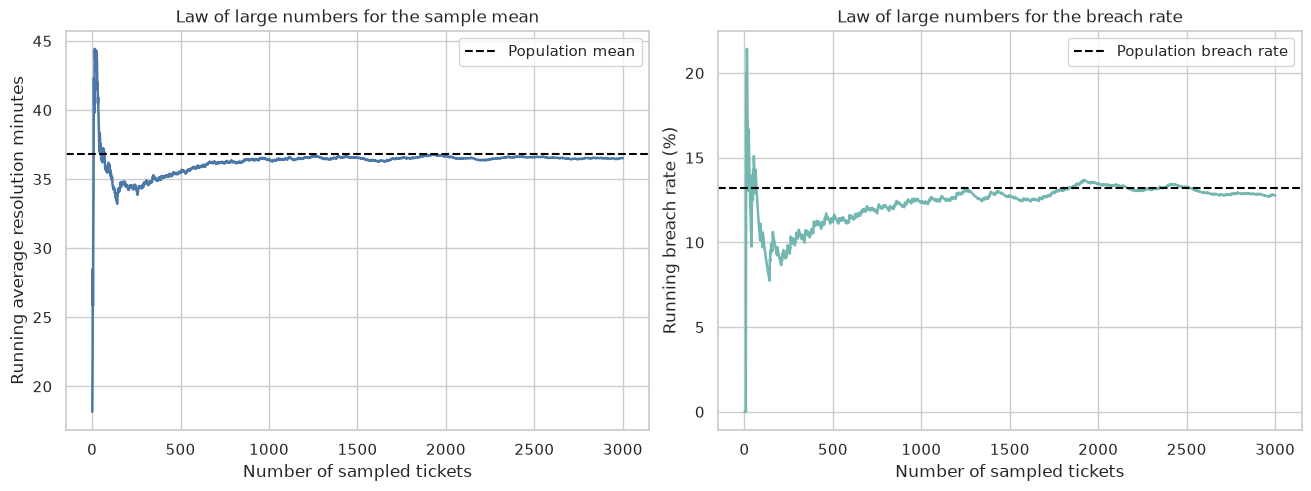

In [3]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
rng = np.random.default_rng(401)
path_size = 3_000
sample_path_idx = rng.integers(0, len(population), size=path_size)
path_resolution = population['resolution_minutes'].to_numpy()[sample_path_idx]
path_breach = population['sla_breach'].to_numpy()[sample_path_idx]

running_mean = np.cumsum(path_resolution) / np.arange(1, path_size + 1)
running_breach = np.cumsum(path_breach) / np.arange(1, path_size + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

axes[0].plot(np.arange(1, path_size + 1), running_mean, color='#4C78A8', linewidth=1.8)
axes[0].axhline(population_mean, color='black', linestyle='--', linewidth=1.5, label='Population mean')
axes[0].set_title('Law of large numbers for the sample mean')
axes[0].set_xlabel('Number of sampled tickets')
axes[0].set_ylabel('Running average resolution minutes')
axes[0].legend()

axes[1].plot(np.arange(1, path_size + 1), 100 * running_breach, color='#72B7B2', linewidth=1.8)
axes[1].axhline(100 * population_breach_rate, color='black', linestyle='--', linewidth=1.5, label='Population breach rate')
axes[1].set_title('Law of large numbers for the breach rate')
axes[1].set_xlabel('Number of sampled tickets')
axes[1].set_ylabel('Running breach rate (%)')
axes[1].legend()

plt.show()


These trajectories are noisy at the beginning because early samples are small. As more tickets accumulate, the estimates become more stable and remain near the population target more consistently.

This is the first reason large samples are valuable. They reduce the amount of random wandering we should expect from the estimator.

## 4. Central Limit Thinking for a Skewed Outcome

The support-ticket outcome distribution is not exactly normal. It is right-skewed: most tickets resolve in a moderate range, while a smaller set of difficult cases create a longer right tail.

Yet the central limit theorem tells us that under broad conditions,

$$
Z_n = \frac{\sqrt{n}(\bar{Y}_n - \mu)}{\sigma} \xrightarrow{d} N(0, 1)
$$

as $n$ becomes large, where $\mu$ is the population mean and $\sigma$ is the population standard deviation.

That statement is about the **sample mean**, not the raw ticket times. We will compare the raw outcome distribution with the standardized sampling distribution of the mean for several sample sizes.


,sample_size,mean_of_standardized_draws,sd_of_standardized_draws,skewness_of_standardized_draws
0,10,-0.014,0.987,0.189
1,40,-0.016,1.014,0.089
2,160,0.003,0.998,0.114


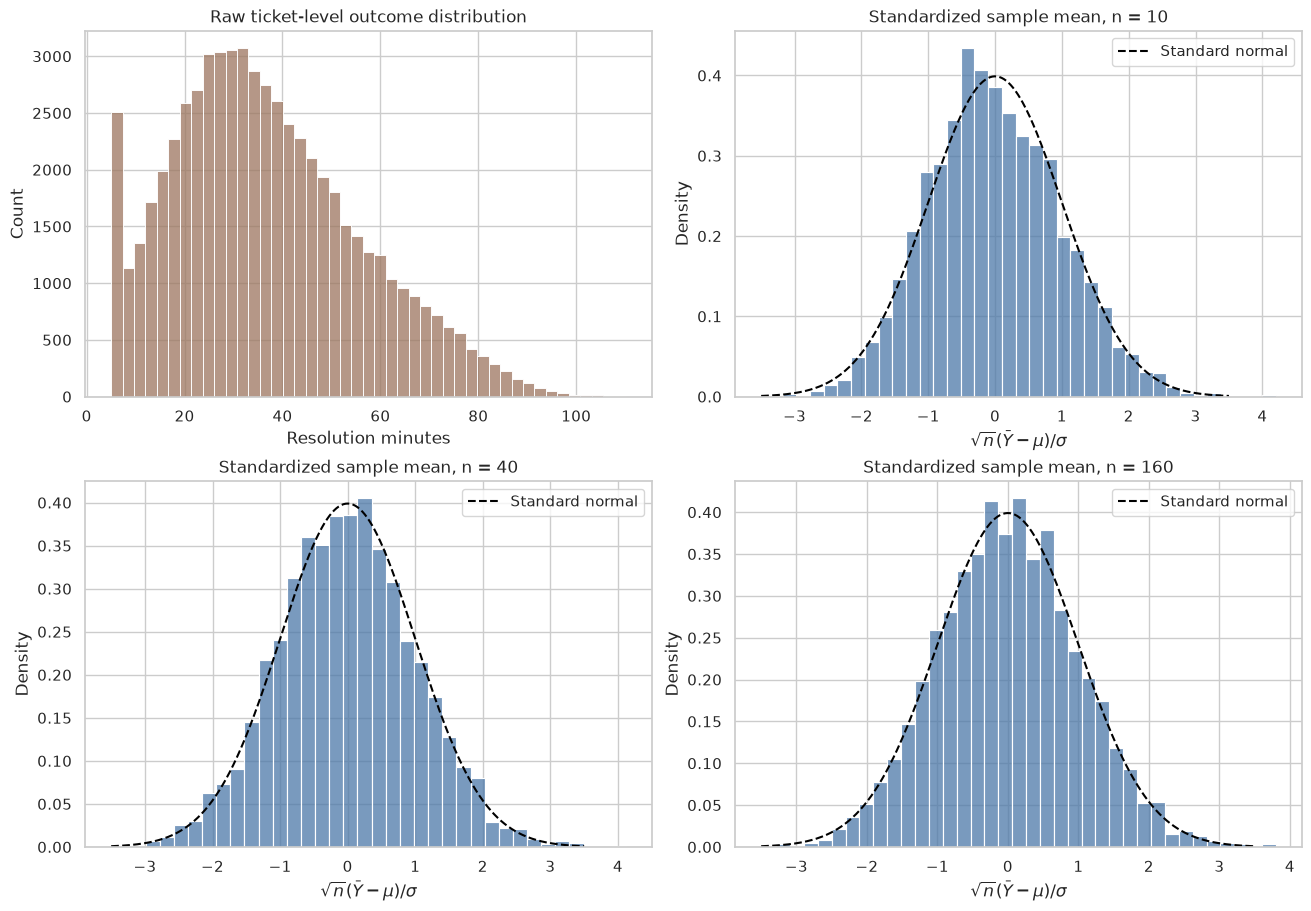

In [4]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
resolution = population['resolution_minutes'].to_numpy()
clt_sizes = [10, 40, 160]
reps = 3_000
rng = np.random.default_rng(505)

clt_draws = {}
clt_summary_rows = []
for n in clt_sizes:
    idx = rng.integers(0, len(resolution), size=(reps, n))
    sample_means = resolution[idx].mean(axis=1)
    z_scores = np.sqrt(n) * (sample_means - population_mean) / population_sd
    clt_draws[n] = z_scores
    clt_summary_rows.append(
        {
            'sample_size': n,
            'mean_of_standardized_draws': f"{z_scores.mean():0.3f}",
            'sd_of_standardized_draws': f"{z_scores.std(ddof=1):0.3f}",
            'skewness_of_standardized_draws': f"{pd.Series(z_scores).skew():0.3f}",
        }
    )

clt_summary = pd.DataFrame(clt_summary_rows)
smart_display(clt_summary)

fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)

sns.histplot(resolution, bins=45, color='#9C755F', ax=axes[0, 0])
axes[0, 0].set_title('Raw ticket-level outcome distribution')
axes[0, 0].set_xlabel('Resolution minutes')
axes[0, 0].set_ylabel('Count')

x = np.linspace(-3.5, 3.5, 400)
for ax, n in zip([axes[0, 1], axes[1, 0], axes[1, 1]], clt_sizes):
    sns.histplot(clt_draws[n], bins=36, stat='density', color='#4C78A8', alpha=0.75, ax=ax)
    ax.plot(x, normal_pdf(x), color='black', linestyle='--', linewidth=1.5, label='Standard normal')
    ax.set_title(f'Standardized sample mean, n = {n}')
    ax.set_xlabel(r'$\sqrt{n}(\bar{Y} - \mu) / \sigma$')
    ax.set_ylabel('Density')
    ax.legend()

plt.show()


This figure captures the central limit theorem in a way that is useful for practice.

- The raw ticket times are visibly skewed.
- The standardized sample mean is already fairly normal-looking even at moderate sample sizes.
- As $n$ grows, the standardized sampling distribution becomes more stable, less skewed, and more closely aligned with the standard normal reference.

This is why asymptotic normal approximations often work well for means, even when the original data are not themselves normally distributed.

## 5. Standard Errors and Asymptotic Intervals in the Observed Audit

The **standard error** is the estimated standard deviation of the estimator's sampling distribution. It is the natural scale of inferential uncertainty.

For the sample mean,

$$
\operatorname{SE}(\bar{Y}) \approx \frac{s}{\sqrt{n}}
$$

For a sample proportion,

$$
\operatorname{SE}(\hat{p}) \approx \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}
$$

We will use these formulas to build ordinary normal-approximation intervals and compare them with bootstrap intervals. Agreement between the two is encouraging, though not a proof of correctness.


In [5]:
# Simulate data or resample observations to study variability and uncertainty.
interval_rows = []

# Mean resolution time
mean_est, mean_se, mean_ci = mean_interval_normal(audit_sample['resolution_minutes'])
mean_boot = bootstrap_distribution(audit_sample['resolution_minutes'].to_numpy(), reps=3_000, seed=601)
interval_rows.append(
    {
        'quantity': 'Mean resolution time',
        'estimate': f"{mean_est:0.2f} minutes",
        'asymptotic_se': f"{mean_se:0.3f}",
        'normal_95_interval': f"[{mean_ci[0]:0.2f}, {mean_ci[1]:0.2f}]",
        'bootstrap_95_interval': f"[{np.quantile(mean_boot, 0.025):0.2f}, {np.quantile(mean_boot, 0.975):0.2f}]",
        'hidden_truth': f"{population_mean:0.2f}",
    }
)

# Overall breach rate
breach_est, breach_se, breach_ci = prop_interval_wald(audit_sample['sla_breach'])
breach_boot = bootstrap_distribution(audit_sample['sla_breach'].to_numpy(), reps=3_000, seed=602)
interval_rows.append(
    {
        'quantity': 'Overall SLA breach rate',
        'estimate': f"{100 * breach_est:0.2f}%",
        'asymptotic_se': f"{100 * breach_se:0.2f}%",
        'normal_95_interval': f"[{100 * breach_ci[0]:0.2f}%, {100 * breach_ci[1]:0.2f}%]",
        'bootstrap_95_interval': f"[{100 * np.quantile(breach_boot, 0.025):0.2f}%, {100 * np.quantile(breach_boot, 0.975):0.2f}%]",
        'hidden_truth': f"{100 * population_breach_rate:0.2f}%",
    }
)

# Enterprise-ticket breach rate
enterprise_est, enterprise_se, enterprise_ci = prop_interval_wald(enterprise_audit['sla_breach'])
enterprise_boot = bootstrap_distribution(enterprise_audit['sla_breach'].to_numpy(), reps=3_000, seed=603)
enterprise_truth = population.query("seller_tier == 'enterprise'")['sla_breach'].mean()
interval_rows.append(
    {
        'quantity': 'Enterprise-ticket breach rate',
        'estimate': f"{100 * enterprise_est:0.2f}%",
        'asymptotic_se': f"{100 * enterprise_se:0.2f}%",
        'normal_95_interval': f"[{100 * enterprise_ci[0]:0.2f}%, {100 * enterprise_ci[1]:0.2f}%]",
        'bootstrap_95_interval': f"[{100 * np.quantile(enterprise_boot, 0.025):0.2f}%, {100 * np.quantile(enterprise_boot, 0.975):0.2f}%]",
        'hidden_truth': f"{100 * enterprise_truth:0.2f}%",
    }
)

interval_table = pd.DataFrame(interval_rows)
smart_display(interval_table)


,quantity,estimate,asymptotic_se,normal_95_interval,bootstrap_95_interval,hidden_truth
0,Mean resolution time,37.33 minutes,0.597,"[36.16, 38.50]","[36.16, 38.50]",36.79
1,Overall SLA breach rate,13.50%,1.08%,"[11.38%, 15.62%]","[11.40%, 15.70%]",13.21%
2,Enterprise-ticket breach rate,18.37%,2.26%,"[13.94%, 22.79%]","[13.95%, 23.13%]",17.21%


For these three quantities, the normal approximation and the bootstrap tell a very similar story. That is a reassuring sign that the large-sample approximation is behaving reasonably.

It is also a reminder that asymptotics are often good enough for operational work when the target is reasonably regular and the effective sample size is not tiny. The enterprise-only breach rate still has noticeable uncertainty because that subgroup contains fewer observations, but the interval is nonetheless stable and interpretable.

## 6. Coverage Improves With Sample Size

An asymptotic interval is useful only if it behaves well across repeated samples. One way to study this is by **empirical coverage**: across many simulated audits, how often does the nominal 95% interval actually contain the true population parameter?

We will check coverage for the mean and the ordinary breach rate across several sample sizes. Then we will separately inspect what happens for the rare critical-failure rate.


,target,sample_size,empirical_coverage
0,Mean resolution time,25,94.0%
1,Overall SLA breach rate,25,85.0%
2,Mean resolution time,60,94.5%
3,Overall SLA breach rate,60,90.8%
4,Mean resolution time,200,94.7%
5,Overall SLA breach rate,200,94.4%
6,Mean resolution time,1000,95.2%
7,Overall SLA breach rate,1000,94.2%


,sample_size,empirical_coverage,intervals_with_negative_lower_bound,all_zero_samples
0,200,61.1%,59.7%,38.9%
1,1000,94.8%,31.0%,1.0%


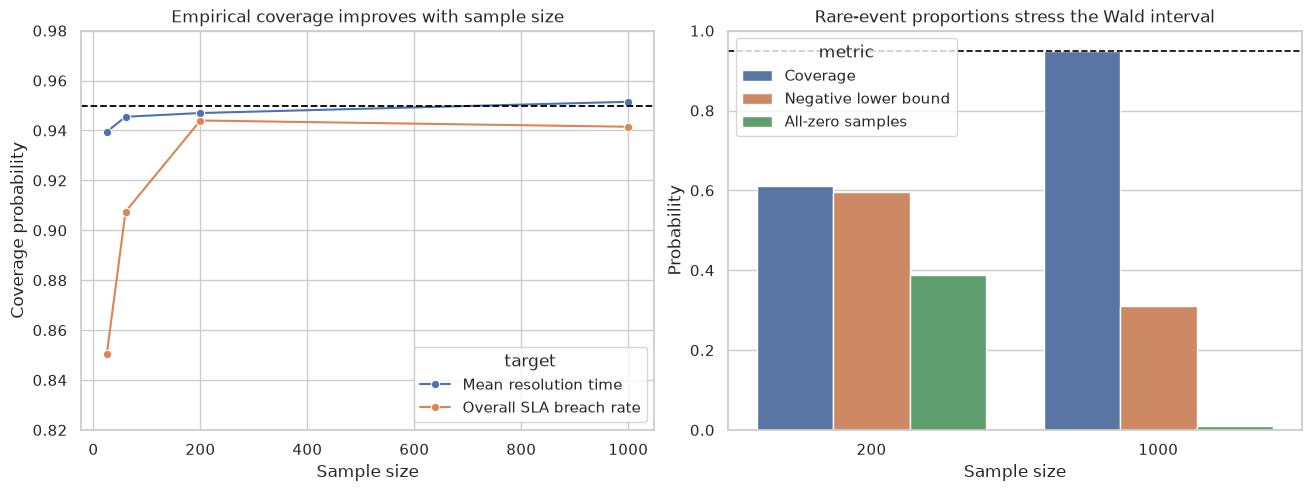

In [6]:
# Visualize the computed results so patterns and diagnostics are easier to interpret.
coverage_sizes = [25, 60, 200, 1_000]
reps = 2_000
rng = np.random.default_rng(701)

y = population['resolution_minutes'].to_numpy()
b = population['sla_breach'].to_numpy()
c = population['critical_failure'].to_numpy()

coverage_rows = []
coverage_plot_rows = []
critical_rows = []

for n in coverage_sizes:
    idx = rng.integers(0, len(population), size=(reps, n))

    y_samples = y[idx]
    y_means = y_samples.mean(axis=1)
    y_ses = y_samples.std(axis=1, ddof=1) / np.sqrt(n)
    y_lower = y_means - 1.96 * y_ses
    y_upper = y_means + 1.96 * y_ses
    mean_coverage = np.mean((y_lower <= population_mean) & (population_mean <= y_upper))

    b_samples = b[idx]
    p_hat = b_samples.mean(axis=1)
    p_se = np.sqrt(p_hat * (1 - p_hat) / n)
    p_lower = p_hat - 1.96 * p_se
    p_upper = p_hat + 1.96 * p_se
    breach_coverage = np.mean((p_lower <= population_breach_rate) & (population_breach_rate <= p_upper))

    coverage_rows.extend(
        [
            {
                'target': 'Mean resolution time',
                'sample_size': n,
                'empirical_coverage': f"{100 * mean_coverage:0.1f}%",
            },
            {
                'target': 'Overall SLA breach rate',
                'sample_size': n,
                'empirical_coverage': f"{100 * breach_coverage:0.1f}%",
            },
        ]
    )
    coverage_plot_rows.extend(
        [
            {'target': 'Mean resolution time', 'sample_size': n, 'coverage': mean_coverage},
            {'target': 'Overall SLA breach rate', 'sample_size': n, 'coverage': breach_coverage},
        ]
    )

for n in [200, 1_000]:
    idx = rng.integers(0, len(population), size=(reps, n))
    c_samples = c[idx]
    c_hat = c_samples.mean(axis=1)
    c_se = np.sqrt(c_hat * (1 - c_hat) / n)
    c_lower = c_hat - 1.96 * c_se
    c_upper = c_hat + 1.96 * c_se

    critical_rows.append(
        {
            'sample_size': n,
            'empirical_coverage': f"{100 * np.mean((c_lower <= population_critical_rate) & (population_critical_rate <= c_upper)):0.1f}%",
            'intervals_with_negative_lower_bound': f"{100 * np.mean(c_lower < 0):0.1f}%",
            'all_zero_samples': f"{100 * np.mean(c_hat == 0):0.1f}%",
        }
    )

coverage_table = pd.DataFrame(coverage_rows)
critical_table = pd.DataFrame(critical_rows)
smart_display(coverage_table)
smart_display(critical_table)

coverage_plot = pd.DataFrame(coverage_plot_rows)
critical_plot = pd.DataFrame(
    [
        {
            'sample_size': row['sample_size'],
            'metric': 'Coverage',
            'value': float(row['empirical_coverage'].strip('%')) / 100,
        }
        for row in critical_rows
    ]
    + [
        {
            'sample_size': row['sample_size'],
            'metric': 'Negative lower bound',
            'value': float(row['intervals_with_negative_lower_bound'].strip('%')) / 100,
        }
        for row in critical_rows
    ]
    + [
        {
            'sample_size': row['sample_size'],
            'metric': 'All-zero samples',
            'value': float(row['all_zero_samples'].strip('%')) / 100,
        }
        for row in critical_rows
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)

sns.lineplot(data=coverage_plot, x='sample_size', y='coverage', hue='target', marker='o', ax=axes[0])
axes[0].axhline(0.95, color='black', linestyle='--', linewidth=1.3, label='95% target')
axes[0].set_title('Empirical coverage improves with sample size')
axes[0].set_xlabel('Sample size')
axes[0].set_ylabel('Coverage probability')
axes[0].set_ylim(0.82, 0.98)

sns.barplot(data=critical_plot, x='sample_size', y='value', hue='metric', ax=axes[1])
axes[1].axhline(0.95, color='black', linestyle='--', linewidth=1.2)
axes[1].set_title('Rare-event proportions stress the Wald interval')
axes[1].set_xlabel('Sample size')
axes[1].set_ylabel('Probability')
axes[1].set_ylim(0, 1.0)

plt.show()


The coverage results tell a nuanced story.

- For the sample mean, the normal approximation is already quite good even at moderate sample sizes, despite skewness in the raw data.
- For the ordinary breach rate, coverage is weaker at very small $n$ but improves as the audit gets larger.
- For the rare critical-failure rate, the ordinary Wald interval is much less trustworthy. At smaller sample sizes it often has negative lower bounds or even degenerates because the sample contains zero critical events.

This is the kind of operational subtlety analysts need to internalize. The label "asymptotic" signals a limiting approximation whose credibility depends on conditions we should actively check.

## 7. A Rare-Event Approximation Can Look Awkward Even in the Observed Audit

The simulation study above is abstractly convincing. But the same issue appears in the observed audit itself.

For the ordinary breach rate, the Wald interval looks reasonable. For the rare critical-failure rate, the same formula can produce a lower bound below zero, which is impossible for a probability. That is a sign that the approximation is mathematically convenient but substantively clumsy for this target.


In [7]:
# Build a summary table that supports the interpretation in the surrounding notes.
observed_failure_rows = []

for label, series in [('Overall SLA breach rate', audit_sample['sla_breach']), ('Critical failure rate (> 90 min)', audit_sample['critical_failure'])]:
    est, se, ci = prop_interval_wald(series)
    observed_failure_rows.append(
        {
            'quantity': label,
            'audit_count_of_events': int(series.sum()),
            'estimate': f"{100 * est:0.3f}%",
            'wald_95_interval': f"[{100 * ci[0]:0.3f}%, {100 * ci[1]:0.3f}%]",
            'n_times_p_hat': f"{len(series) * est:0.2f}",
        }
    )

observed_failure_table = pd.DataFrame(observed_failure_rows)
smart_display(observed_failure_table)


,quantity,audit_count_of_events,estimate,wald_95_interval,n_times_p_hat
0,Overall SLA breach rate,135,13.500%,"[11.382%, 15.618%]",135.00
1,Critical failure rate (> 90 min),3,0.300%,"[-0.039%, 0.639%]",3.00


This table gives a practical rule of thumb. When $n\hat{p}$ is comfortably large, the ordinary normal approximation tends to behave more sensibly. When the event count is tiny, the approximation can become unstable or visually absurd.

We do not need to panic when this happens. We simply need to recognize that rare-event inference often calls for different tools or more careful interval constructions than the basic Wald formula.

## 8. Decision Memo Using Asymptotic Reasoning

Suppose leadership proposes a simple decision rule: expand the enterprise support promise only if the enterprise-ticket breach rate appears credibly below **15%**.

We will use the enterprise-only audit sample, compute the normal approximation interval, compare it with the bootstrap interval, and issue a recommendation.


In [8]:
# Simulate data or resample observations to study variability and uncertainty.
threshold = 0.15

enterprise_boot_low = np.quantile(enterprise_boot, 0.025)
enterprise_boot_high = np.quantile(enterprise_boot, 0.975)

if enterprise_ci[1] < threshold and enterprise_boot_high < threshold:
    recommendation = 'Proceed with the broader enterprise support promise.'
    rationale = 'Both asymptotic and bootstrap uncertainty summaries keep the enterprise breach rate below the decision threshold.'
elif enterprise_est < threshold:
    recommendation = 'Continue the pilot, but do not expand externally yet.'
    rationale = 'The point estimate is near the target, but uncertainty remains too wide for a strong promise.'
else:
    recommendation = 'Delay expansion and improve service reliability before scaling the promise.'
    rationale = 'The estimated enterprise breach rate is above the threshold, and both uncertainty summaries leave substantial probability mass above the acceptable risk level.'

memo = (
    f"### Decision Memo\n\n"
    f"**Recommendation:** {recommendation}\n\n"
    f"**Evidence summary:**\n\n"
    f"- Enterprise-ticket breach estimate: **{100 * enterprise_est:0.2f}%** based on **{len(enterprise_audit)}** audited enterprise tickets.\n"
    f"- Asymptotic normal interval: **[{100 * enterprise_ci[0]:0.2f}%, {100 * enterprise_ci[1]:0.2f}%]**.\n"
    f"- Bootstrap interval: **[{100 * enterprise_boot_low:0.2f}%, {100 * enterprise_boot_high:0.2f}%]**.\n"
    f"- Decision threshold: **{100 * threshold:0.1f}%** enterprise breach rate.\n\n"
    f"**Interpretation:** {rationale}\n\n"
    f"The normal approximation is appropriate enough here because the enterprise segment sample is moderately sized and the bootstrap tells a very similar story. Even so, the decision should be framed as an uncertainty-aware recommendation, not as a mechanically certain verdict (Greenland et al., 2016; Wasserstein et al., 2019)."
)

display(Markdown(memo))


### Decision Memo

**Recommendation:** Delay expansion and improve service reliability before scaling the promise.

**Evidence summary:**

- Enterprise-ticket breach estimate: **18.37%** based on **294** audited enterprise tickets.
- Asymptotic normal interval: **[13.94%, 22.79%]**.
- Bootstrap interval: **[13.95%, 23.13%]**.
- Decision threshold: **15.0%** enterprise breach rate.

**Interpretation:** The estimated enterprise breach rate is above the threshold, and both uncertainty summaries leave substantial probability mass above the acceptable risk level.

The normal approximation is appropriate enough here because the enterprise segment sample is moderately sized and the bootstrap tells a very similar story. Even so, the decision should be framed as an uncertainty-aware recommendation, not as a mechanically certain verdict (Greenland et al., 2016; Wasserstein et al., 2019).

<!-- real-data-companion-course01 -->
## Real-Data Companion: Sampling Distributions from RAND HIE

The synthetic examples made repeated sampling visible because we controlled the population. RAND HIE lets us repeat the same idea with a real, skewed, count-valued outcome. We treat the available RAND HIE table as a finite empirical population and repeatedly sample from it to study how estimates behave as sample size changes.

The unit is a person-period record, the main outcome is outpatient physician visits (`mdvis`), and the key grouping variable is assigned cost sharing through `lncoins`. The exercise compares sample means and contrasts across repeated samples, which makes asymptotic ideas more concrete than formulas alone.

This companion is not claiming that the available file is the literal policy universe. It uses the full dataset as a teaching population so we can see how sampling distributions tighten with larger samples and how skewed outcomes can slow normal approximations. This connects asymptotic theory to a real measurement scale.

Data source: [RAND Health Insurance Experiment in statsmodels](https://www.statsmodels.org/stable/datasets/generated/randhie.html).

,sample_size,mean_of_sample_means,sampling_sd,p05,p95
0,50,2.873,0.687,1.940,4.160
1,200,2.853,0.317,2.325,3.380
2,1000,2.858,0.145,2.630,3.102


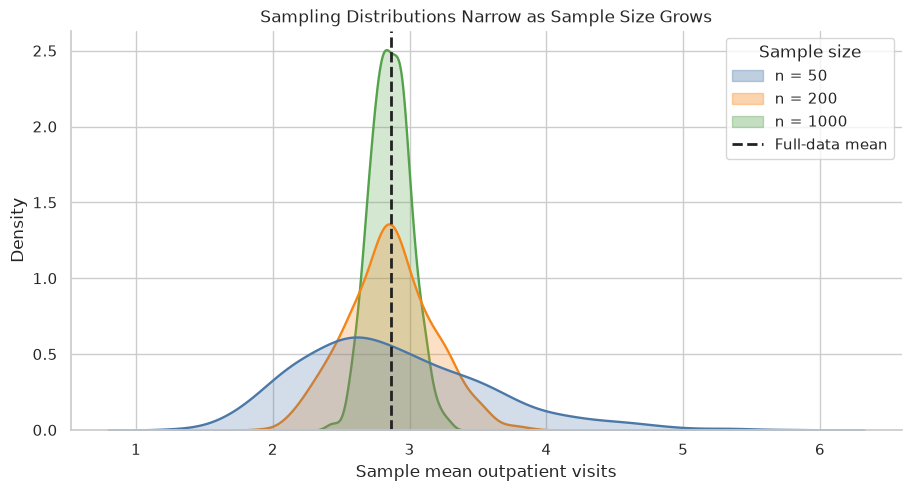

In [9]:
# real-data-companion-course01
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio root so shared notebook helpers import reliably.
    
    Parameters:
        start: Starting path for the upward project-root search.
    
    Returns:
        A `Path` pointing to the nearest portfolio root that contains `notebooks/_shared`; if no such parent is found, the original starting path is returned.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.display import smart_display
from notebooks._shared.real_data import load_statsmodels_randhie, optional_data_note

RUN_REAL_DATA_COMPANION = True

if RUN_REAL_DATA_COMPANION:
    rng_real = np.random.default_rng(2026)
    rand_hie = load_statsmodels_randhie()
    population_mean = rand_hie["mdvis"].mean()

    records = []
    draws = []
    for sample_size in [50, 200, 1_000]:
        means = np.array([
            rand_hie["mdvis"].sample(sample_size, replace=True, random_state=int(rng_real.integers(1_000_000))).mean()
            for _ in range(800)
        ])
        records.append(
            {
                "sample_size": sample_size,
                "mean_of_sample_means": means.mean(),
                "sampling_sd": means.std(ddof=1),
                "p05": np.quantile(means, 0.05),
                "p95": np.quantile(means, 0.95),
            }
        )
        draws.append(pd.DataFrame({"sample_size": str(sample_size), "sample_mean": means}))

    sampling_summary = pd.DataFrame(records)
    sampling_draws = pd.concat(draws, ignore_index=True)
    smart_display(sampling_summary.round(3))

    fig, ax = plt.subplots(figsize=(9, 4.8), constrained_layout=True)
    sample_size_order = ["50", "200", "1000"]
    sample_size_palette = {"50": "#4C78A8", "200": "#F58518", "1000": "#54A24B"}
    sns.kdeplot(
        data=sampling_draws,
        x="sample_mean",
        hue="sample_size",
        hue_order=sample_size_order,
        palette=sample_size_palette,
        fill=True,
        common_norm=False,
        alpha=0.25,
        linewidth=1.7,
        legend=False,
        ax=ax,
    )
    ax.axvline(population_mean, color="#222222", linestyle="--", linewidth=2)
    ax.set_title("Sampling Distributions Narrow as Sample Size Grows")
    ax.set_xlabel("Sample mean outpatient visits")
    ax.set_ylabel("Density")
    legend_handles = [
        Patch(facecolor=sample_size_palette[label], edgecolor=sample_size_palette[label], alpha=0.35, label=f"n = {label}")
        for label in sample_size_order
    ]
    legend_handles.append(Line2D([0], [0], color="#222222", linestyle="--", linewidth=2, label="Full-data mean"))
    ax.legend(handles=legend_handles, title="Sample size", frameon=True, loc="upper right")
    sns.despine(fig=fig)
    plt.show()
else:
    optional_data_note(
        "RAND Health Insurance Experiment",
        "https://www.statsmodels.org/stable/datasets/generated/randhie.html",
        "RUN_REAL_DATA_COMPANION",
    )

<!-- real-data-companion-course01 -->
The real-data version preserves the main lesson from the synthetic section. Larger samples produce tighter sampling distributions, but the center remains tied to the target being sampled. Because physician visits are skewed and zero-heavy, the sampling distribution is not a perfect classroom bell curve at small sample sizes. That is exactly why asymptotic reasoning should be paired with a check of the outcome distribution.

## 9. What to Remember

1. The distribution of the estimator is different from the distribution of the raw data.
2. The law of large numbers explains stabilization; the central limit theorem explains approximate normality of many estimators.
3. Standard errors are the working scale of inferential uncertainty.
4. Asymptotic normal intervals can work well for means and moderate-rate proportions, even when the underlying data are skewed.
5. Rare events are a classic place where naive large-sample formulas become fragile.
6. Good decision science does not use asymptotics blindly; it checks whether the approximation is sensible for the target and sample size at hand.

The next notebook moves from sampling-distribution intuition to the formal logic of likelihood and maximum likelihood estimation.


## References

- Efron, B. (1979). *Bootstrap Methods: Another Look at the Jackknife*. *The Annals of Statistics, 7*(1). [https://doi.org/10.1214/aos/1176344552](https://doi.org/10.1214/aos/1176344552)
- Greenland, S., Senn, S. J., Rothman, K. J., Carlin, J. B., Poole, C., Goodman, S. N., & Altman, D. G. (2016). *Statistical tests, P values, confidence intervals, and power: a guide to misinterpretations*. *European Journal of Epidemiology, 31*(4), 337-350. [https://doi.org/10.1007/s10654-016-0149-3](https://doi.org/10.1007/s10654-016-0149-3)
- Raftery, A. E. (2016). *Use and communication of probabilistic forecasts*. *Statistical Analysis and Data Mining: The ASA Data Science Journal, 9*(6), 397-410. [https://doi.org/10.1002/sam.11302](https://doi.org/10.1002/sam.11302)
- Wasserstein, R. L., Schirm, A. L., & Lazar, N. A. (2019). *Moving to a World Beyond "p < 0.05"*. *The American Statistician, 73*(sup1), 1-19. [https://doi.org/10.1080/00031305.2019.1583913](https://doi.org/10.1080/00031305.2019.1583913)
